In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import torch
from pathlib import Path 
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
set_seed(0) 

## Loading the catalog
We load the catalog like in the previous notebook.

In [3]:
catalog_ds_class = catalog.Catalog.by_name(f"{'ChuanDian'}-Standard")
catalog_ds = catalog_ds_class(root_dir='/home/yzzhang/pjt/chuandian_eq/data/ChuanDian/raw',catalog_file='/home/yzzhang/pjt/chuandian_eq/data/ChuanDian/raw/Chuandian2021.dat')

Loading existing catalog from /home/yzzhang/pjt/chuandian_eq/data/ChuanDian/raw.


## Loading a trained model
All models trained on the default versions of the catalog are stored in `{PROJECT_ROOT_DIR}/trained_models/`.

In [4]:
import importlib
importlib.import_module("src.models")    

<module 'src.models' from '/home/yzzhang/pjt/chuandian_eq/src/models/__init__.py'>

In [5]:
from src.models.tpp.thp import THP
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint
checkpoint_dir = Path("../checkpoints/thp_20250716-224801")
args = load_args_from_checkpoint(None, torch.load(checkpoint_dir / "best_model_1.pth"))
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model.set_attn_type("flash")
model.set_attn_dropout(0)  

model = torch.compile(model)
model.eval() 

OptimizedModule(
  (_orig_mod): THP(
    (base_model): BaseModel(
      (encoder): Transformer(
        (encoder): Encoder(
          (layer_stacks): ModuleDict(
            (default): ModuleList(
              (0): EncoderLayer(
                (slf_attn): MultiHeadAttention(
                  (w_qs): Linear(in_features=32, out_features=128, bias=False)
                  (w_ks): Linear(in_features=32, out_features=128, bias=False)
                  (w_vs): Linear(in_features=32, out_features=128, bias=False)
                  (fc): Linear(in_features=128, out_features=32, bias=True)
                  (layer_norm): LayerNorm((32,), eps=1e-06, elementwise_affine=True)
                  (dropout): Dropout(p=0.1, inplace=False)
                  (attn_modules): ModuleDict(
                    (full): FullAttention(
                      (dropout): Dropout(p=0, inplace=False)
                    )
                    (flash): FlashAttentionWrapper()
                  )
                )
  

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

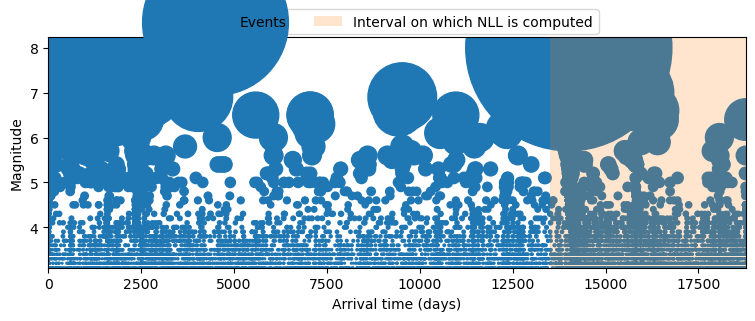

In [6]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
visualize_sequence(test_seq, show_nll=True)

In [7]:
catalog_ds.test[0]

Sequence(
  inter_times: [11598],
  arrival_times: [11597],
  t_start: 0.0,
  t_end: 18771.0,
  t_nll_start: 13514.0,
  mag: [11597],
  loc: [11597, 2],
  depth: [11597]
)

We would like to generate a 7-day forecast for the interval `[4000, 4007]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 4000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[4000, 4007]`.

In [8]:
t_forecast = 18000 # 4000 13000
duration =60 # 7
num_samples = 1000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast) #  3500
# Observed events in the 7-day forecast window
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)

## Generate the forecast

In [9]:
past_seq

Sequence(
  inter_times: [10854],
  arrival_times: [10853],
  t_start: 0.0,
  t_end: 18000.0,
  t_nll_start: 13514.0,
  mag: [10853],
  loc: [10853, 2],
  depth: [10853]
)

In [10]:
past_batch = src.data.Batch.from_list([past_seq])
# print(past_batch.inter_times)
print(past_batch.arrival_times.shape)
print(past_batch.mag.shape)
print(past_batch.input_mask.shape)

torch.Size([1, 10854])
torch.Size([1, 10854])
torch.Size([1, 10854])


In [11]:
torch.mean(past_batch.inter_times)

tensor(1.6584)

In [12]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

In [13]:
past_seq.float()

Sequence(
  inter_times: [10854],
  arrival_times: [10853],
  t_start: 0.0,
  t_end: 18000.0,
  t_nll_start: 13514.0,
  mag: [10853],
  loc: [10853, 2],
  depth: [10853]
)

In [14]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 200
for _ in range(num_samples // samples_per_batch):
    forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[4000, 4007]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [15]:
forecast

[Sequence(
   inter_times: [9],
   arrival_times: [8],
   t_start: 18000.0,
   t_end: 18060.0,
   t_nll_start: 18000.0,
   mag: [8]
 ),
 Sequence(
   inter_times: [18],
   arrival_times: [17],
   t_start: 18000.0,
   t_end: 18060.0,
   t_nll_start: 18000.0,
   mag: [17]
 ),
 Sequence(
   inter_times: [20],
   arrival_times: [19],
   t_start: 18000.0,
   t_end: 18060.0,
   t_nll_start: 18000.0,
   mag: [19]
 ),
 Sequence(
   inter_times: [17],
   arrival_times: [16],
   t_start: 18000.0,
   t_end: 18060.0,
   t_nll_start: 18000.0,
   mag: [16]
 ),
 Sequence(
   inter_times: [16],
   arrival_times: [15],
   t_start: 18000.0,
   t_end: 18060.0,
   t_nll_start: 18000.0,
   mag: [15]
 ),
 Sequence(
   inter_times: [34],
   arrival_times: [33],
   t_start: 18000.0,
   t_end: 18060.0,
   t_nll_start: 18000.0,
   mag: [33]
 ),
 Sequence(
   inter_times: [30],
   arrival_times: [29],
   t_start: 18000.0,
   t_end: 18060.0,
   t_nll_start: 18000.0,
   mag: [29]
 ),
 Sequence(
   inter_times: [21

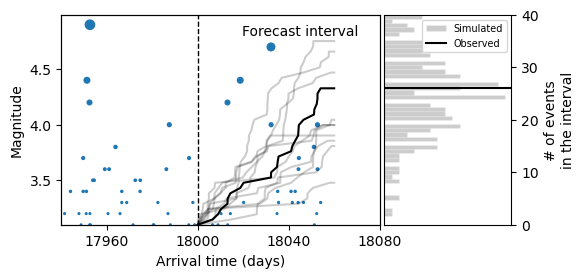

In [ ]:
src.utils.visualization.visualize_trajectories(test_seq, forecast,save_path=checkpoint_dir/"forecast.png")